In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from dataclasses import dataclass, field, asdict
from enum import Enum
from typing import Callable
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
import os
import random
import json
from pathlib import Path
import rich

2025-02-20 11:20:23.494579: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-20 11:20:23.513418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740046823.535246   44808 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740046823.541669   44808 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-20 11:20:23.564547: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# To ensure reproductiblity
def set_seed(seed: int):
    random.seed(seed)

    np.random.seed(seed)

    tf.random.set_seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

    physical_devices = tf.config.experimental.list_physical_devices("GPU")
    if physical_devices:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        tf.config.threading.set_intra_op_parallelism_threads(1)
        tf.config.threading.set_inter_op_parallelism_threads(1)

set_seed(1234)

2025-02-20 11:20:32.748838: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


En première partie on définit quelques fonctions utilitaires permettant une gestion plus fluide du chargement des bases d'images utilisées.
On normalise les images dans [0, 1] en pré-traitement.

In [3]:
# Use an enum for datasets to avoid mistyping
class Dsets(str, Enum):
    mnist = "mnist"
    fmnist = "fashion_mnist"
    cifar10 = "cifar10"
    cifar100 = "cifar100"


# Use an enum for D1,D2 pair to avoid mistyping
class Dset_pairs(tuple[Dsets, Dsets], Enum):
    mnist_fmnist = (Dsets.mnist, Dsets.fmnist)
    half_mnist = (Dsets.mnist, Dsets.mnist)
    half_cifar10 = (Dsets.cifar10, Dsets.cifar10)
    half_cifar100 = (Dsets.cifar100, Dsets.cifar100)


# Just a regular dataclass to handle the config logic
@dataclass
class Config:
    batch_size: int = 64
    epochs: int = 5
    loss: str = "sparse_categorical_crossentropy"
    optimizer: str = "adam"
    metrics: list[str] = field(default_factory=lambda: ["accuracy"])

    dset_pair: Dset_pairs = Dset_pairs.mnist_fmnist
    p: float = 1.0

    @property
    def input_shape(self) -> tuple[int, int, int]:
        if self.dset_pair in [
            Dset_pairs.half_cifar10,
            Dset_pairs.half_cifar100,
        ]:
            return (32, 32, 3)

        return (28, 28, 1)

    @property
    def half_dset(self) -> bool:
        if self.dset_pair in [
            Dset_pairs.half_cifar10,
            Dset_pairs.half_cifar100,
            Dset_pairs.half_mnist,
        ]:
            return True

        return False


# Define loading/preprocess functions for each available datasets


# To allow for [0, 1] normalization
def preprocess(image: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def load_mnist() -> tuple[tf.data.Dataset, tf.data.Dataset, int, dict[int, str]]:
    (mnist_train, mnist_test), mnist_info = tfds.load(
        "mnist", split=["train", "test"], as_supervised=True, with_info=True
    )

    class_names = {
        i: mnist_info.features["label"].int2str(i)
        for i in range(mnist_info.features["label"].num_classes)
    }
    return (
        mnist_train,
        mnist_test,
        mnist_info.features["label"].num_classes,
        class_names,
    )


def load_fmnist() -> tuple[tf.data.Dataset, tf.data.Dataset, int, dict[int, str]]:
    (fmnist_train, fmnist_test), fmnist_info = tfds.load(
        "fashion_mnist", split=["train", "test"], as_supervised=True, with_info=True
    )
    class_names = {
        i: fmnist_info.features["label"].int2str(i)
        for i in range(fmnist_info.features["label"].num_classes)
    }
    return (
        fmnist_train,
        fmnist_test,
        fmnist_info.features["label"].num_classes,
        class_names,
    )


def load_cifar10() -> tuple[tf.data.Dataset, tf.data.Dataset, int, dict[int, str]]:
    (cifar10_train, cifar10_test), cifar10_info = tfds.load(
        "cifar10", split=["train", "test"], as_supervised=True, with_info=True
    )

    class_names = {
        i: cifar10_info.features["label"].int2str(i)
        for i in range(cifar10_info.features["label"].num_classes)
    }
    return (
        cifar10_train,
        cifar10_test,
        cifar10_info.features["label"].num_classes,
        class_names,
    )


def load_cifar100() -> tuple[tf.data.Dataset, tf.data.Dataset, int, dict[int, str]]:
    (cifar100_train, cifar100_test), cifar100_info = tfds.load(
        "cifar100", split=["train", "test"], as_supervised=True, with_info=True
    )

    class_names = {
        i: cifar100_info.features["label"].int2str(i)
        for i in range(cifar100_info.features["label"].num_classes)
    }
    return (
        cifar100_train,
        cifar100_test,
        cifar100_info.features["label"].num_classes,
        class_names,
    )


LOAD_MAPPER: dict[
    Dsets : Callable[None, tuple[tf.data.Dataset, tf.data.Dataset, int, dict[int, str]]]
] = {
    Dsets.mnist: load_mnist,
    Dsets.fmnist: load_fmnist,
    Dsets.cifar10: load_cifar10,
    Dsets.cifar100: load_cifar100,
}


def split_dset_in_half(
    train_dset: tf.data.Dataset,
    test_dset: tf.data.Dataset,
    class_names: dict[int, str],
    config: Config,
) -> tuple[
    tf.data.Dataset, tf.data.Dataset, tf.data.Dataset, tf.data.Dataset, dict[int, str]
]:
    num_classes = len(class_names)
    D1_classes = tf.constant(list(range(num_classes // 2)), dtype=tf.int64)
    D2_classes = tf.constant(list(range(num_classes // 2, num_classes)), dtype=tf.int64)

    # This is really annoying but we relied on the filter method on TF that is done dynamically
    # which means that the cardinality is in fact unknown where we splitted dataset into 2 sub-datasets,
    # in that situation we need to manually compute the size of the dataset by iterating over it...
    def reset_cardinality(dset):
        cardinality = dset.reduce(0, lambda x, _: x + 1).numpy()
        return dset.apply(tf.data.experimental.assert_cardinality(cardinality))

    D1_train = (
        reset_cardinality(
            train_dset.filter(
                lambda _, label: tf.math.reduce_any(tf.equal(label, D1_classes))
            )
        )
        .map(preprocess)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    D2_train = (
        reset_cardinality(
            train_dset.filter(
                lambda _, label: tf.math.reduce_any(tf.equal(label, D2_classes))
            )
        )
        .map(preprocess)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    D1_test = (
        reset_cardinality(
            test_dset.filter(
                lambda _, label: tf.math.reduce_any(tf.equal(label, D1_classes))
            )
        )
        .map(preprocess)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    D2_test = (
        reset_cardinality(
            test_dset.filter(
                lambda _, label: tf.math.reduce_any(tf.equal(label, D2_classes))
            )
        )
        .map(preprocess)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    return (
        D1_train,
        D2_train,
        D1_test,
        D2_test,
        class_names,
    )


# Function to merge labels from a dataset pairs by shifting their index
def merge_datasets(
    config: Config,
) -> tuple[
    tf.data.Dataset, tf.data.Dataset, tf.data.Dataset, tf.data.Dataset, dict[int, str]
]:
    global LOAD_MAPPER

    D1_train, D1_test, D1_classes, D1_names = LOAD_MAPPER[config.dset_pair[0]]()
    if config.half_dset:
        return split_dset_in_half(D1_train, D1_test, D1_names, config)

    D2_train, D2_test, _, D2_names = LOAD_MAPPER[config.dset_pair[1]]()

    offset_D1_label = lambda img, lbl: (img, lbl)
    offset_D2_label = lambda img, lbl: (
        img,
        lbl + D1_classes,
    )  # Shift labels

    D1_train = (
        D1_train.map(preprocess)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
        .map(offset_D1_label)
    )
    D2_train = (
        D2_train.map(preprocess)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
        .map(offset_D2_label)
    )

    D1_test = (
        D1_test.map(preprocess)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
        .map(offset_D1_label)
    )
    D2_test = (
        D2_test.map(preprocess)
        .batch(config.batch_size)
        .prefetch(tf.data.AUTOTUNE)
        .map(offset_D2_label)
    )

    merged_class_names = {
        **D1_names,
        **{i + D1_classes: name for i, name in D2_names.items()},
    }

    return (
        D1_train,
        D2_train,
        D1_test,
        D2_test,
        merged_class_names,
    )


# This function is used for experience replay and just create a new dataset by adding a fraction
# of the other dataset in the first one. We assume that the same batch size is used for the two dsets
def experience_replay(
    new_dset: tf.data.Dataset, old_dset: tf.data.Dataset, p: float
) -> tf.data.Dataset:
    cardinality = old_dset.cardinality().numpy()

    sample_size = int(p * cardinality)
    samples = old_dset.take(sample_size)

    er_dset = new_dset.concatenate(samples)

    return er_dset.shuffle(buffer_size=er_dset.cardinality().numpy()).prefetch(
        tf.data.AUTOTUNE
    )

On effectue quelques essais pour voir si les fonctions donnent des retours cohérents.

In [4]:
# Half cifar10
config = Config(dset_pair=Dset_pairs.half_cifar10)
d1_train, d2_train, d1_test, d2_test, merged_class_names = merge_datasets(config)
for images, labels in d1_train.take(1):
    rich.print(images.shape, labels.shape)

# Half cifar100
config = Config(dset_pair=Dset_pairs.half_cifar100)
d1_train, d2_train, d1_test, d2_test, merged_class_names = merge_datasets(config)
for images, labels in d1_train.take(1):
    rich.print(images.shape, labels.shape)

# Half mnist
config = Config(dset_pair=Dset_pairs.half_mnist)
d1_train, d2_train, d1_test, d2_test, merged_class_names = merge_datasets(config)
for images, labels in d1_train.take(1):
    rich.print(images.shape, labels.shape)

# Mnsit_fmnist
config = Config(dset_pair=Dset_pairs.mnist_fmnist)
d1_train, d2_train, d1_test, d2_test, merged_class_names = merge_datasets(config)
for images, labels in d1_train.take(1):
    rich.print(images.shape, labels.shape)

# Try experience replay to mix-datasets
er_train = experience_replay(d2_train, d1_train, 0.2)
for images, labels in er_train.take(1):
    rich.print(images.shape, labels.shape)

2025-02-20 11:20:46.110143: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:376] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


(64, 32, 32, 3) (64,)

2025-02-20 11:20:53.527689: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(64, 32, 32, 3) (64,)

2025-02-20 11:21:01.159005: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(64, 28, 28, 1) (64,)

2025-02-20 11:21:08.817247: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


(64, 28, 28, 1) (64,)

2025-02-20 11:21:08.821700: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-02-20 11:21:11.406606: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


(64, 28, 28, 1) (64,)

On donne quelques fonctions de visualisations rapides de la base dans la cellule suivante.

In [5]:
def visualize_images(
    dataset: tf.data.Dataset, class_names: dict[int, str], cmap="gray", title="D1 train"
) -> None:
    images, labels = next(dataset.shuffle(1000).take(1).as_numpy_iterator())

    fig, ax = plt.subplots(3, 3, figsize=(8, 8))
    for i in range(9):
        row, col = i // 3, i % 3
        ax[row, col].imshow(images[i], cmap=cmap)
        ax[row, col].set_title(class_names.get(labels[i], f"Class {labels[i]}"))
        ax[row, col].axis("off")

    fig.tight_layout()
    fig.suptitle(title, fontsize=16)
    fig.subplots_adjust(top=0.85)
    plt.show()


def plot_class_distribution(
    dataset: tf.data.Dataset, num_classes: int, title: str = "D1 train"
) -> None:
    class_counts = np.zeros(num_classes, dtype=int)

    for _, labels in dataset.as_numpy_iterator():
        labels = labels.flatten()  # Ensure it's a 1D array
        unique, counts = np.unique(labels, return_counts=True)
        class_counts[unique] += counts  # Efficiently update class counts

    plt.figure(figsize=(8, 5))
    plt.bar(
        range(num_classes),
        class_counts,
        tick_label=[str(i) for i in range(num_classes)],
        color="skyblue",
    )
    plt.xlabel("Class Index")
    plt.xticks([])  # Ugly when there's too many classes otherwise
    plt.ylabel("Frequency")
    plt.title(f"Class Distribution in Dataset {title}", fontsize=16)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

Quelques essais de visualisations, comme on s'y attend les bases fusionnées ont bien 0 instances des classes de l'autre.

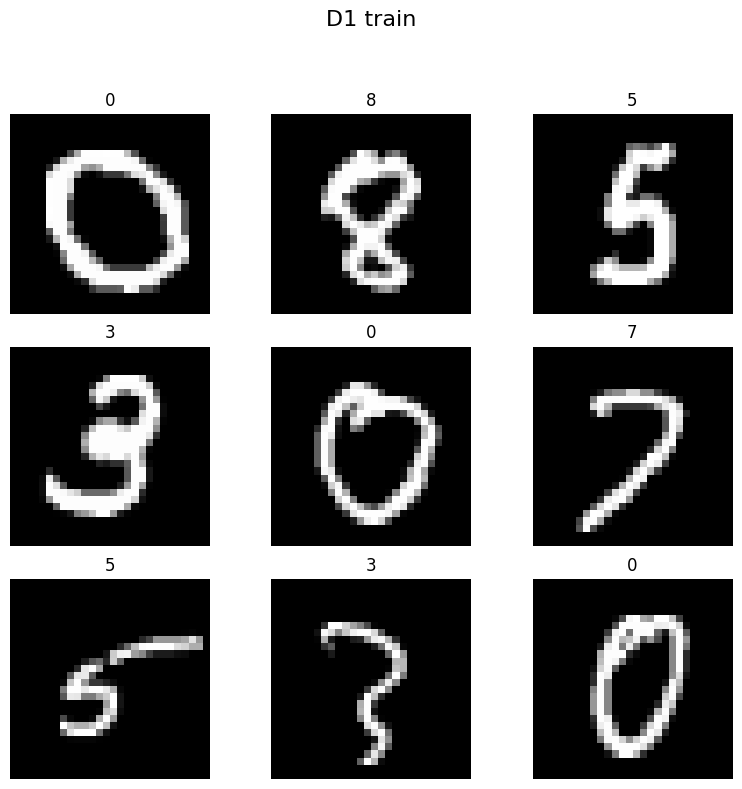

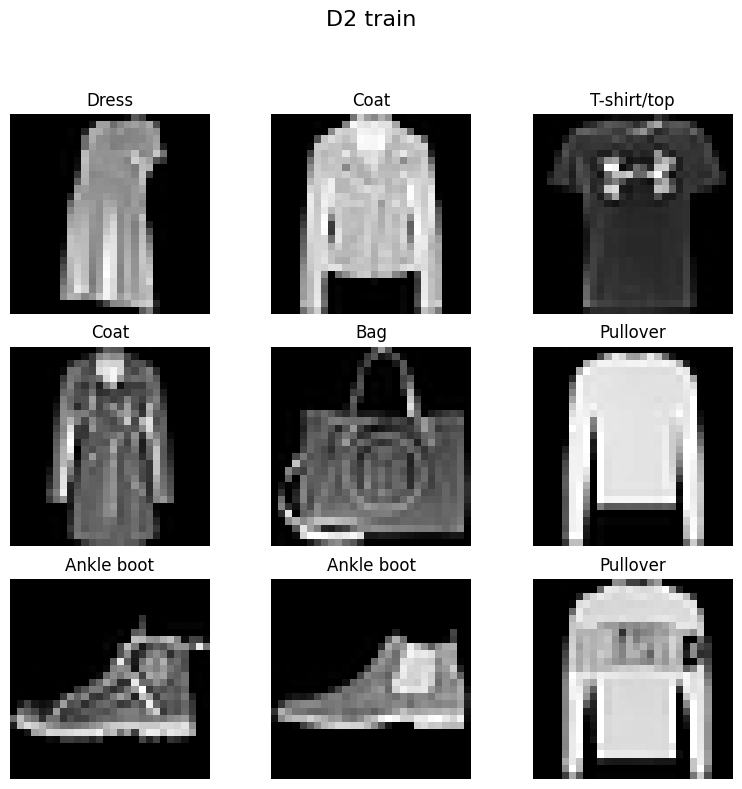

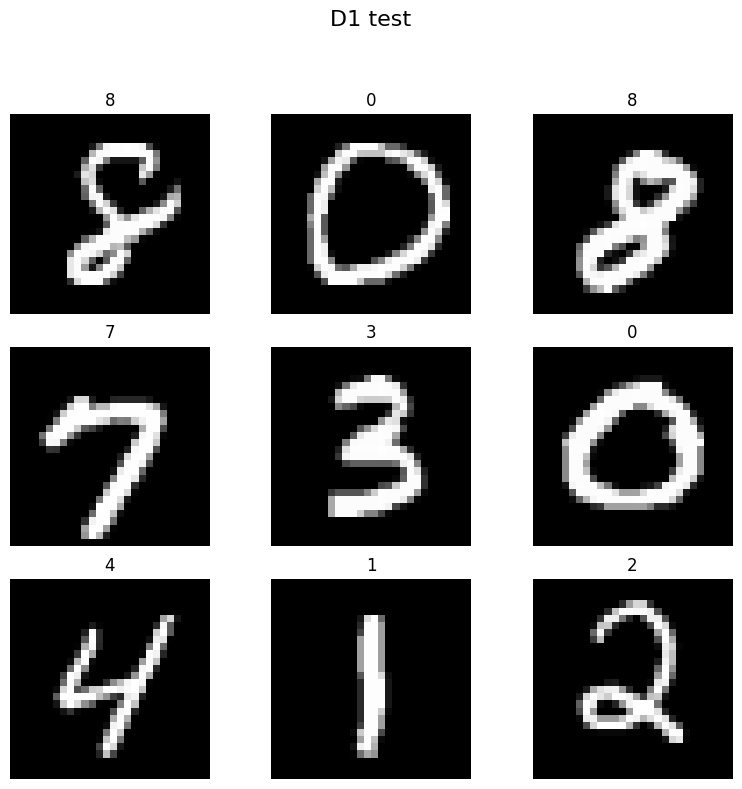

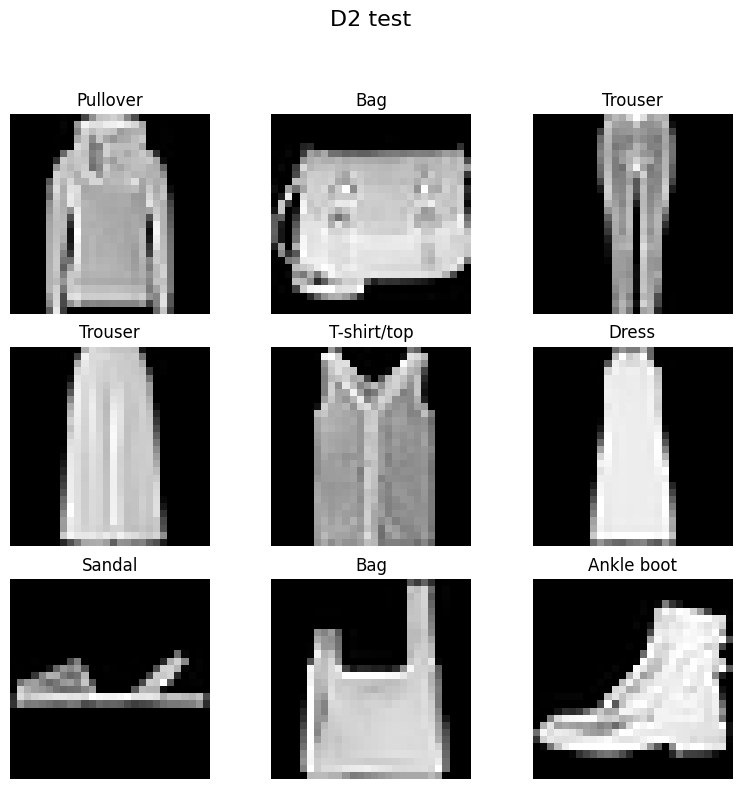

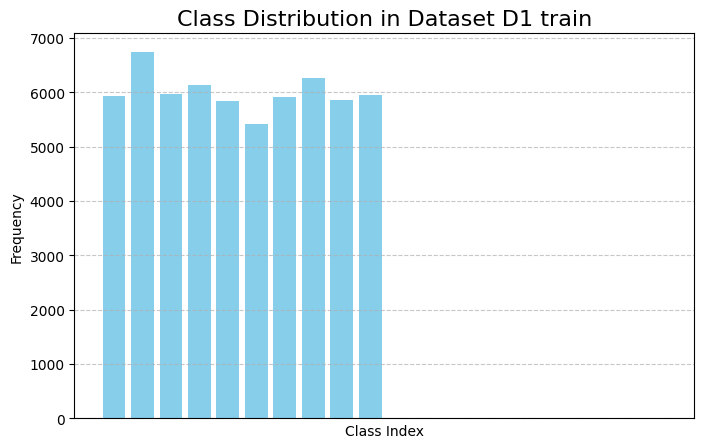

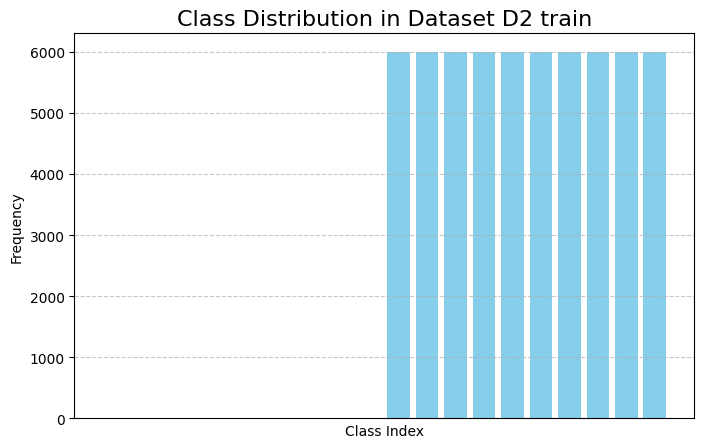

2025-02-20 11:21:38.488441: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


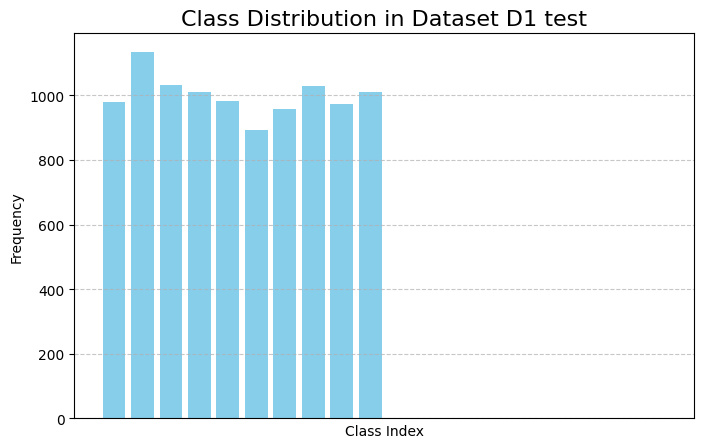

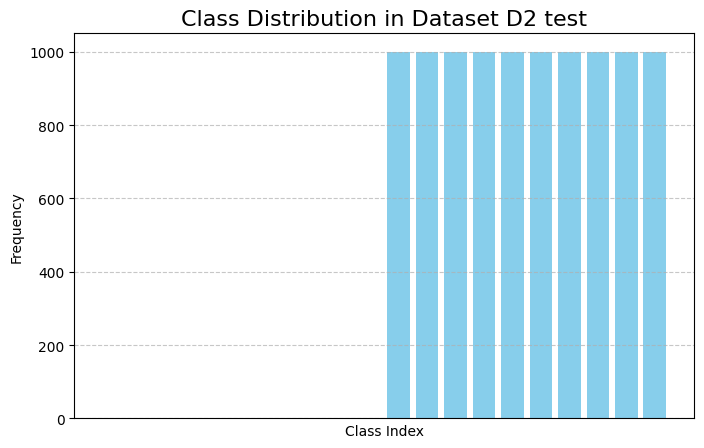

In [6]:
# Fmnist-Mnist
config = Config()
d1_train, d2_train, d1_test, d2_test, class_names = merge_datasets(config)

visualize_images(d1_train, class_names, title="D1 train")
visualize_images(d2_train, class_names, title="D2 train")

visualize_images(d1_test, class_names, title="D1 test")
visualize_images(d2_test, class_names, title="D2 test")

plot_class_distribution(d1_train, num_classes=len(class_names), title="D1 train")
plot_class_distribution(d2_train, num_classes=len(class_names), title="D2 train")

plot_class_distribution(d1_test, num_classes=len(class_names), title="D1 test")
plot_class_distribution(d2_test, num_classes=len(class_names), title="D2 test")

On remarque que la base F-MNIST est strictement homogène en terme de nombre d'instance par classe contrairement à MNIST qui elle ne l'est pas exactement.

Dans la suite on définit la logique d'entrainement et le réseau de convolution employé.
En particulier on emploi un CNN basique avec 3 couches de convolutions 3x3, avec ReLU comme fonction d'activation, des MaxPoolin2D successifs et 2 couches denses de décisions comportant respectivement 128 neuronnes (avec ReLU comme fonction d'activation) et nombre de classes avec une fonction softmax pour donner une probabilité d'appartenance à une classe.
Pour l'entrainement on prend les paramètres par défaut donnés dans la classe Config, c'est-à-dire 5 epochs, la fonction coût utilisée est l'entropie croisée (en particulier la sparse_categorical_crossentropy car les annotations sont sous format entier).
On suit la précision comme métrique de performance du modèle, et l'optimiseur Adam est employé avec les paramètres par défaut de TF.

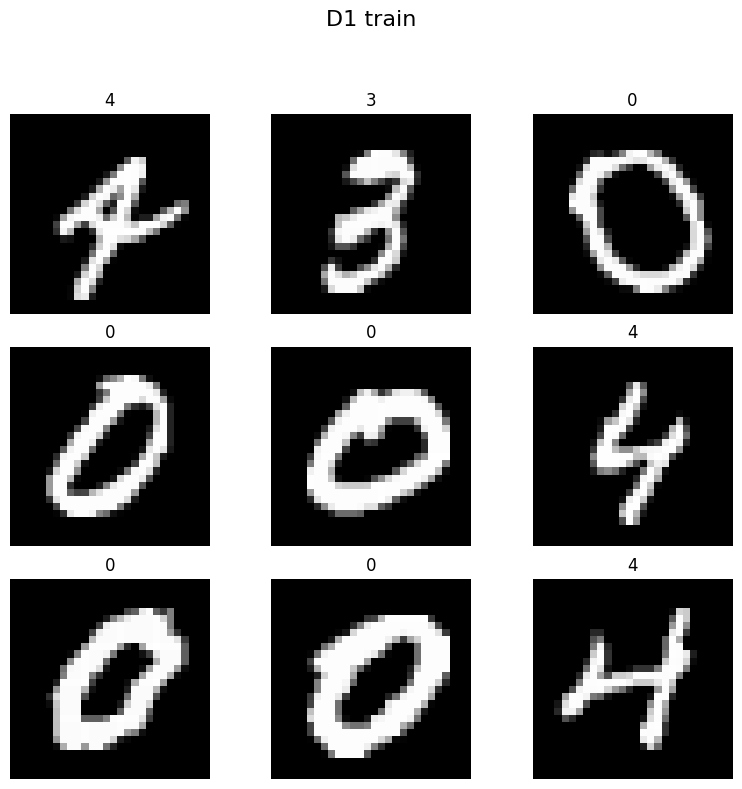

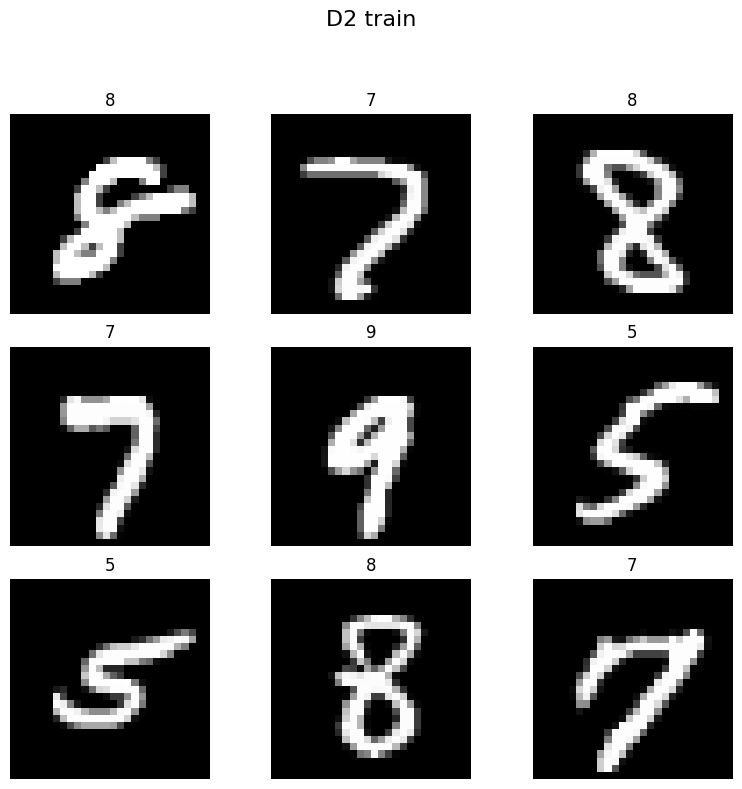

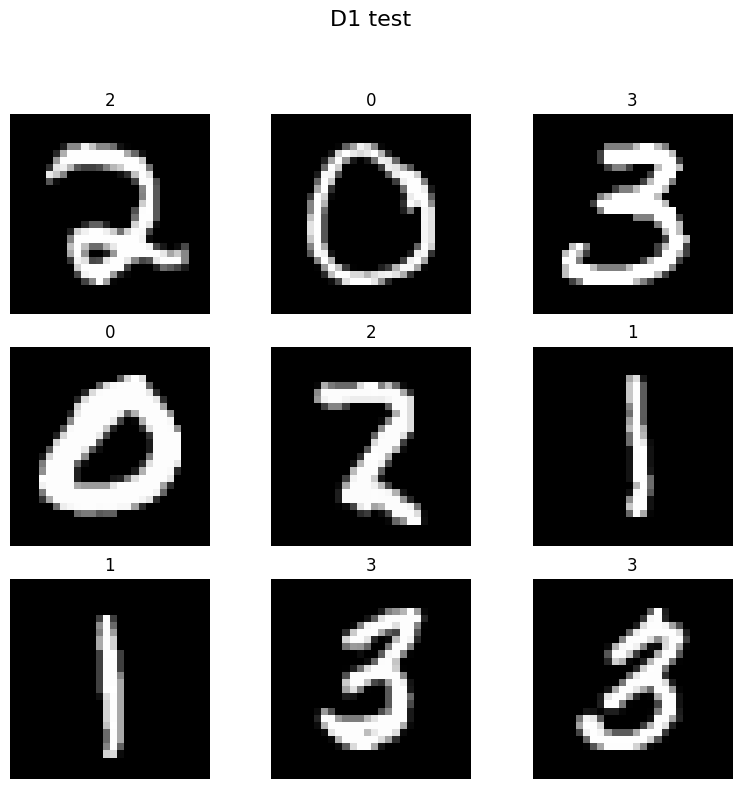

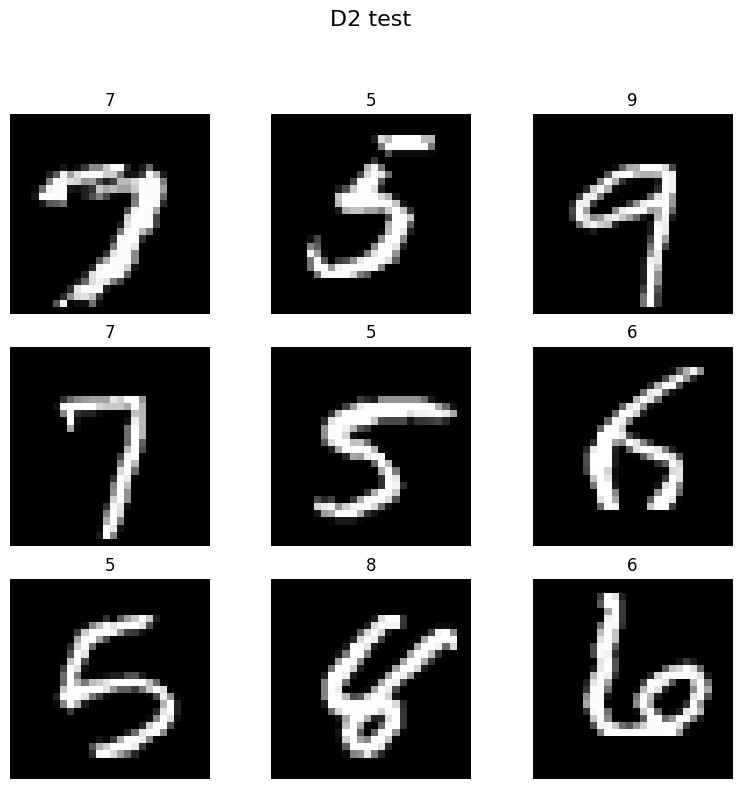

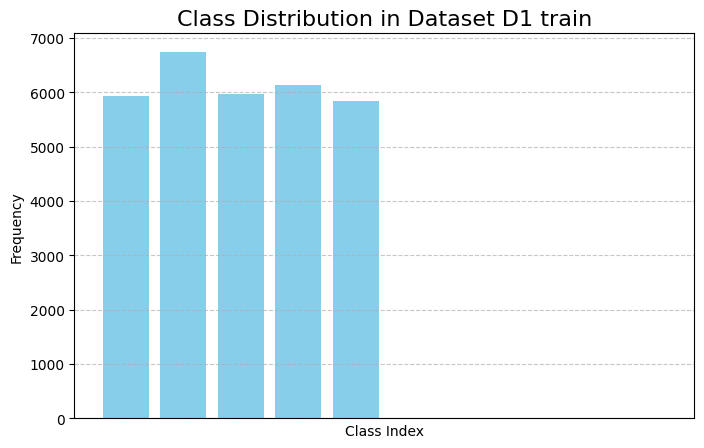

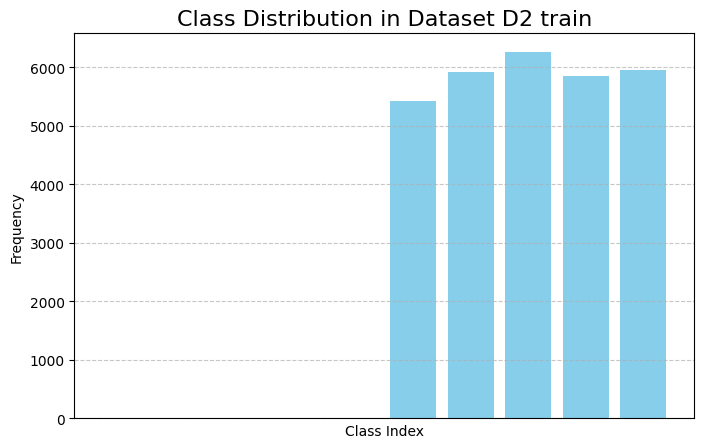

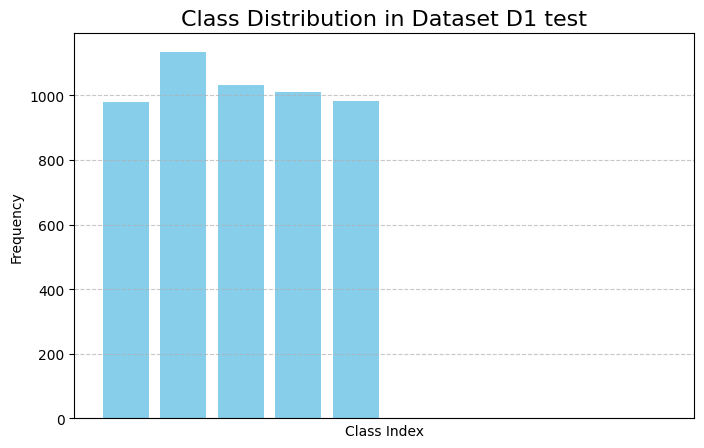

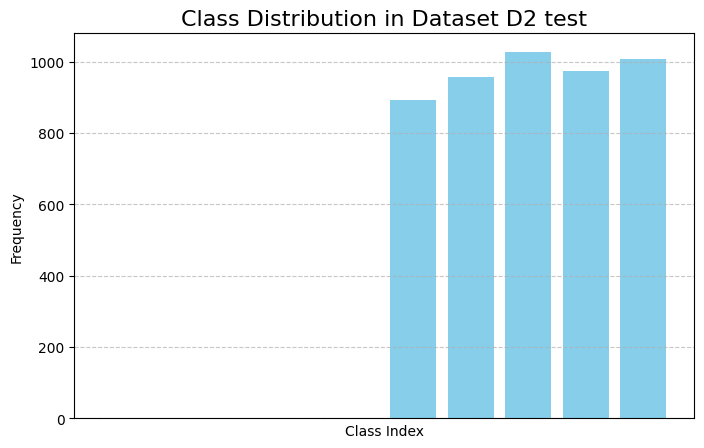

In [7]:
# Half-mnist
config = Config(dset_pair=Dset_pairs.half_mnist)
d1_train, d2_train, d1_test, d2_test, class_names = merge_datasets(config)

visualize_images(d1_train, class_names, title="D1 train")
visualize_images(d2_train, class_names, title="D2 train")

visualize_images(d1_test, class_names, title="D1 test")
visualize_images(d2_test, class_names, title="D2 test")

plot_class_distribution(d1_train, num_classes=len(class_names), title="D1 train")
plot_class_distribution(d2_train, num_classes=len(class_names), title="D2 train")

plot_class_distribution(d1_test, num_classes=len(class_names), title="D1 test")
plot_class_distribution(d2_test, num_classes=len(class_names), title="D2 test")

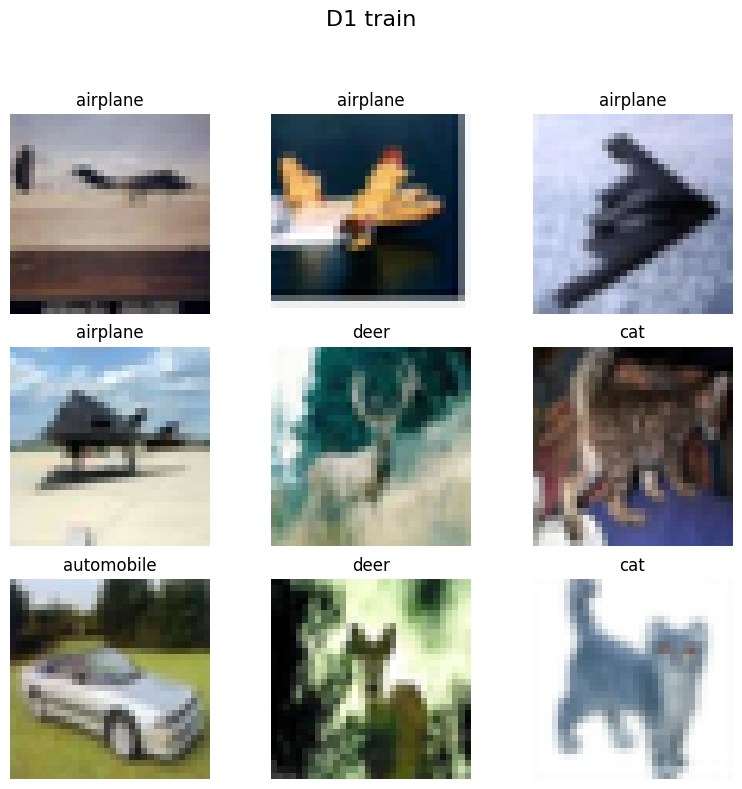

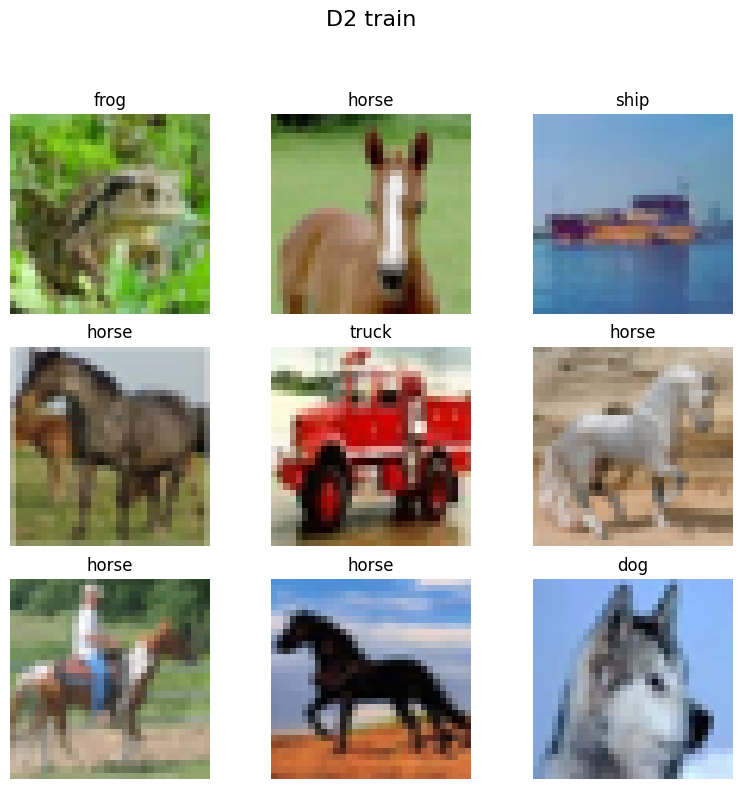

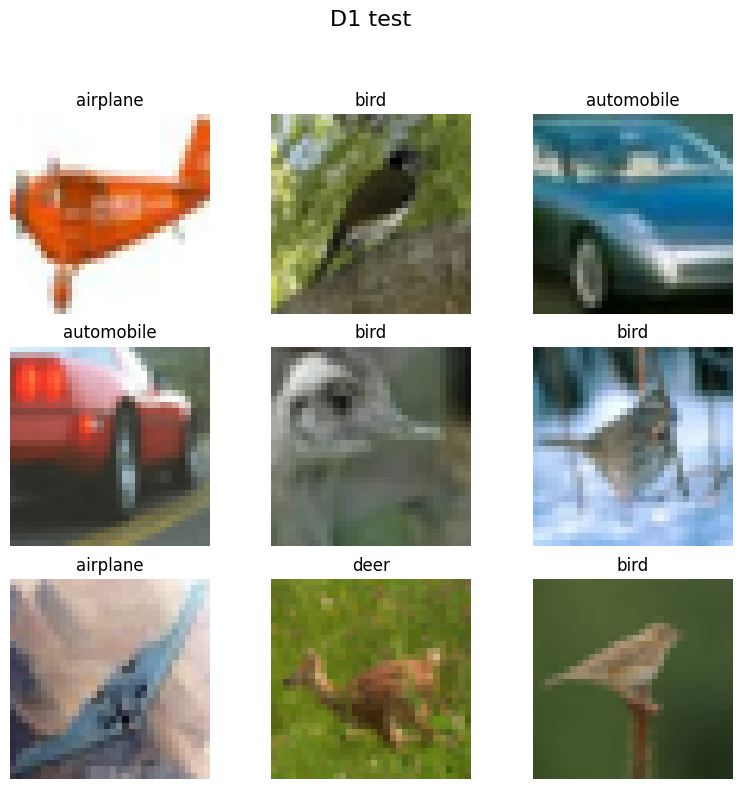

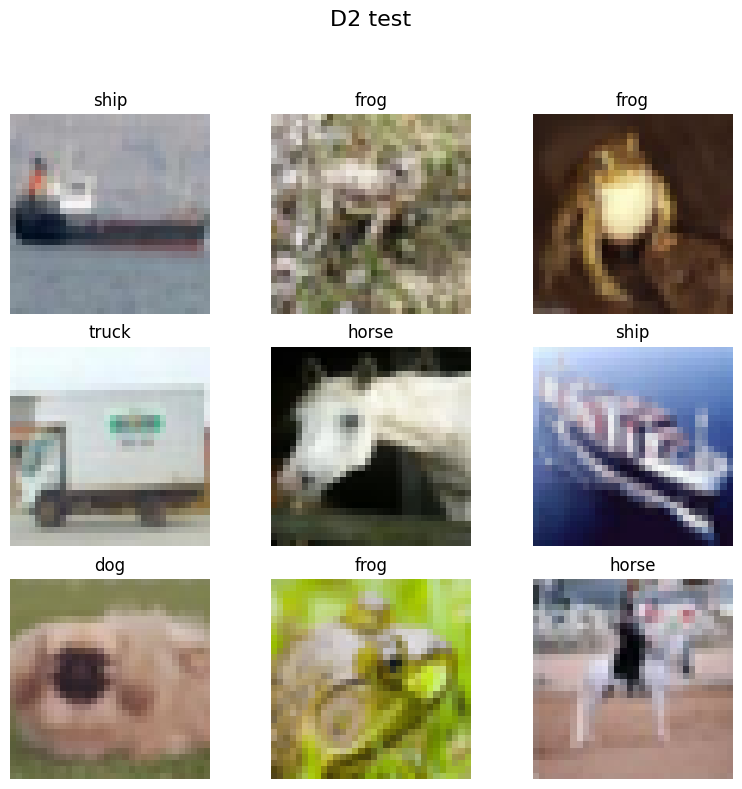

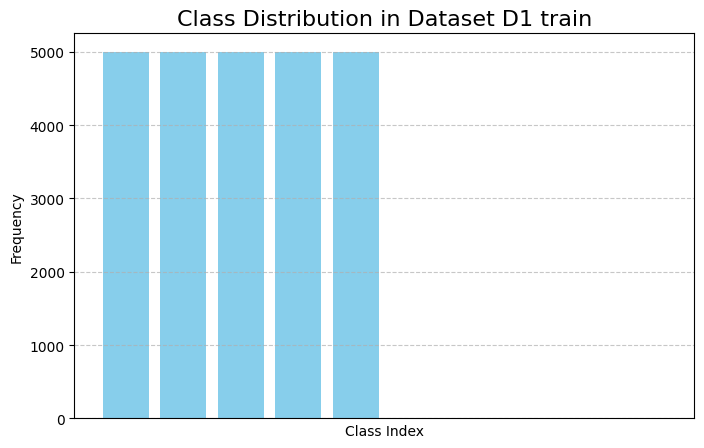

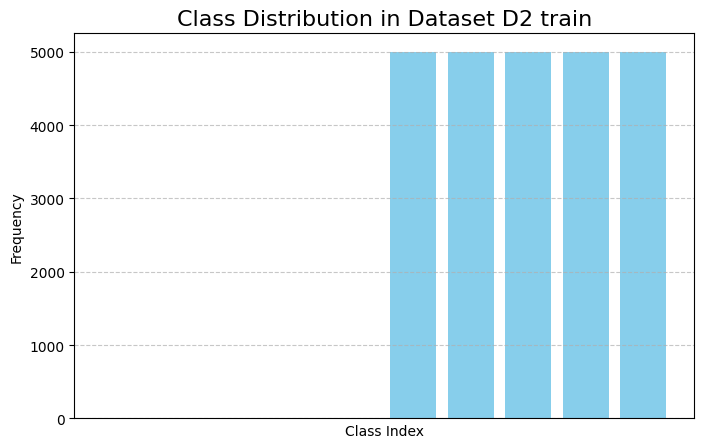

2025-02-20 11:22:25.087294: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


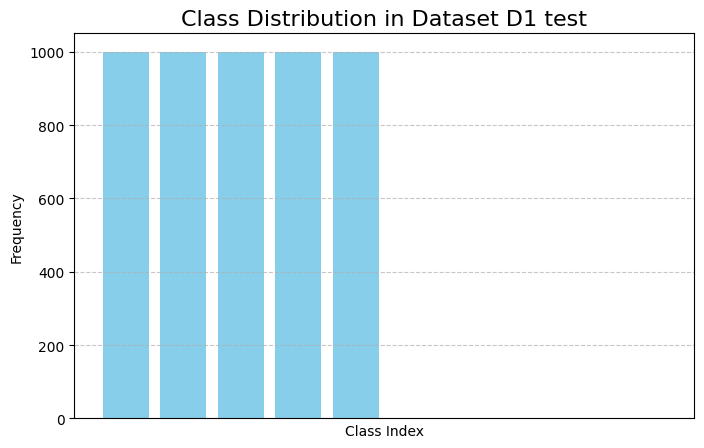

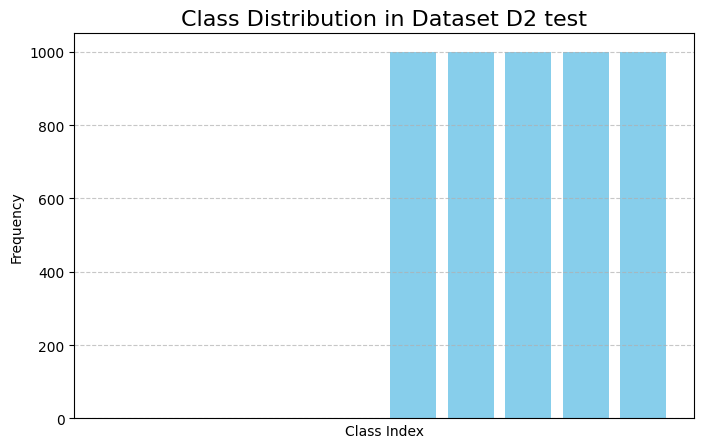

In [8]:
# Half-cifar10
config = Config(dset_pair=Dset_pairs.half_cifar10)
d1_train, d2_train, d1_test, d2_test, class_names = merge_datasets(config)

visualize_images(d1_train, class_names, title="D1 train")
visualize_images(d2_train, class_names, title="D2 train")

visualize_images(d1_test, class_names, title="D1 test")
visualize_images(d2_test, class_names, title="D2 test")

plot_class_distribution(d1_train, num_classes=len(class_names), title="D1 train")
plot_class_distribution(d2_train, num_classes=len(class_names), title="D2 train")

plot_class_distribution(d1_test, num_classes=len(class_names), title="D1 test")
plot_class_distribution(d2_test, num_classes=len(class_names), title="D2 test")

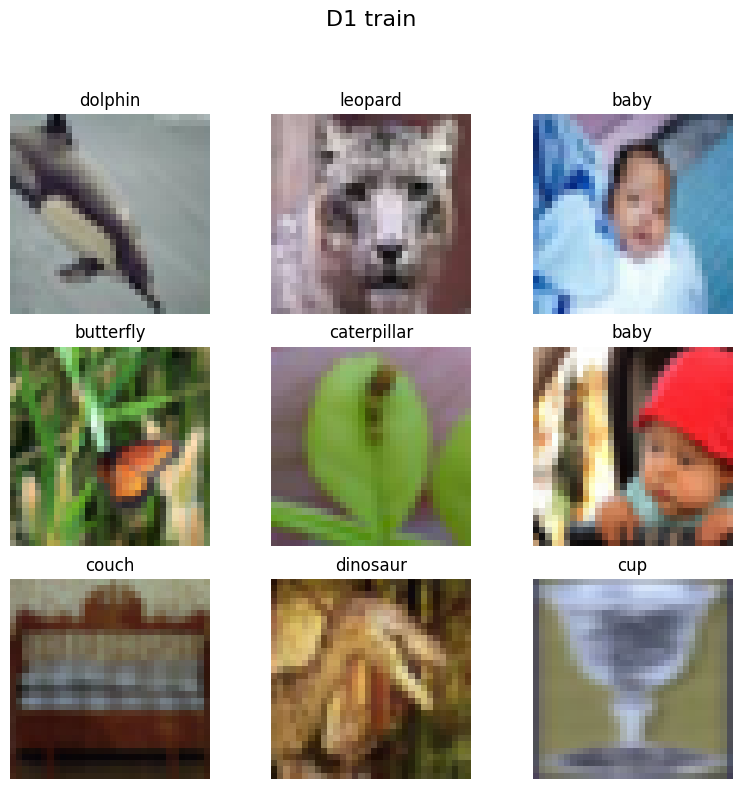

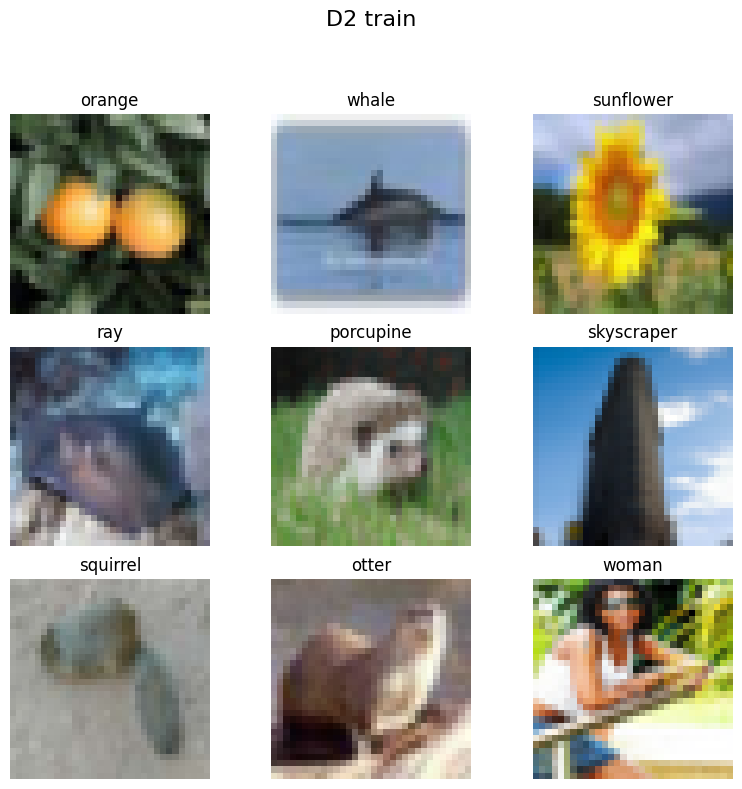

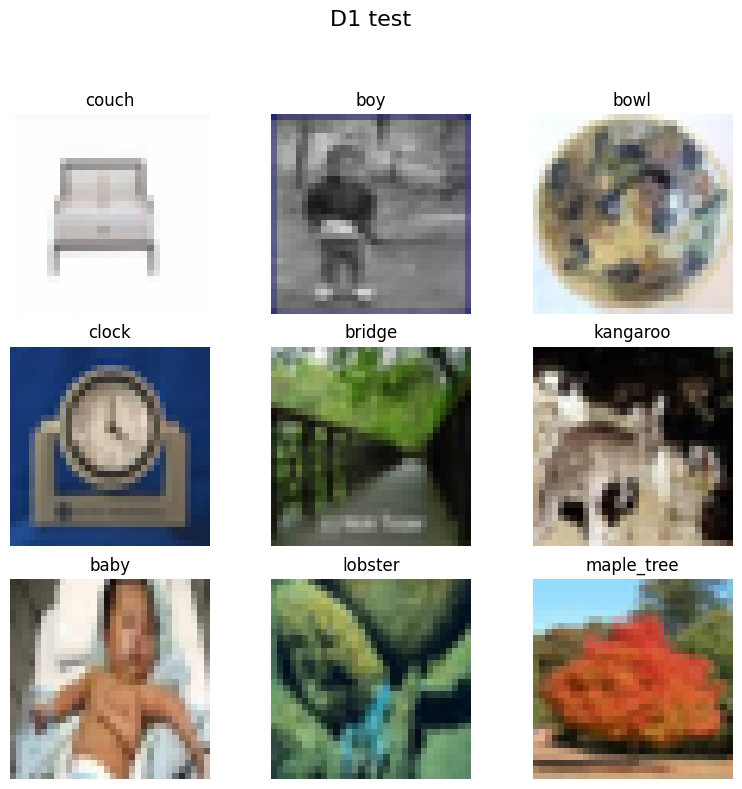

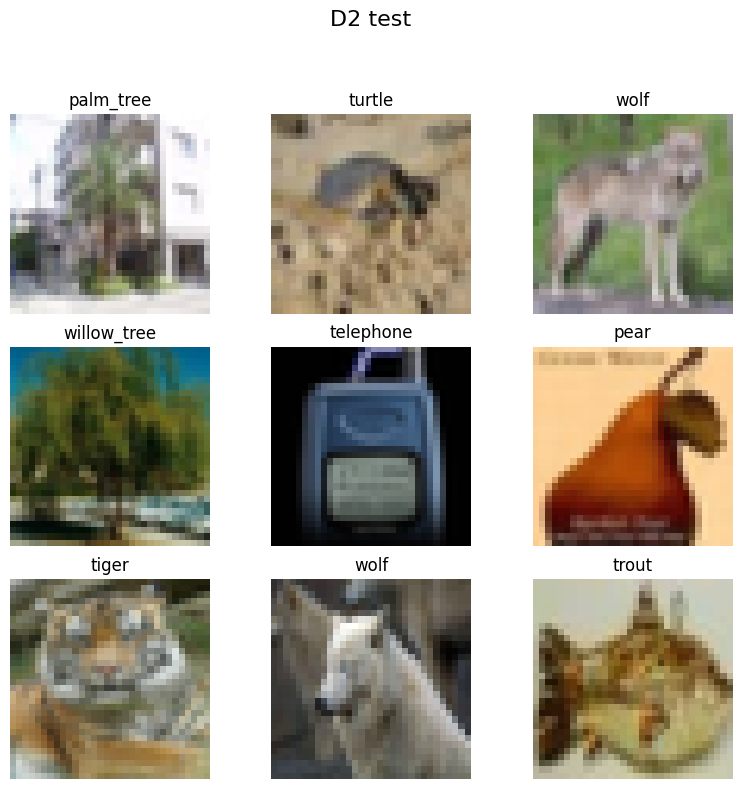

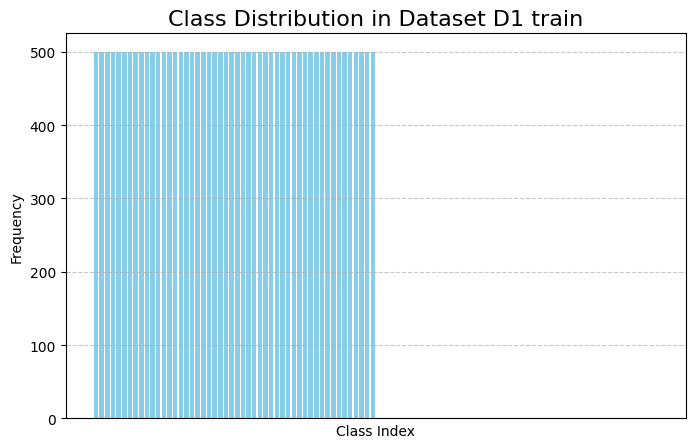

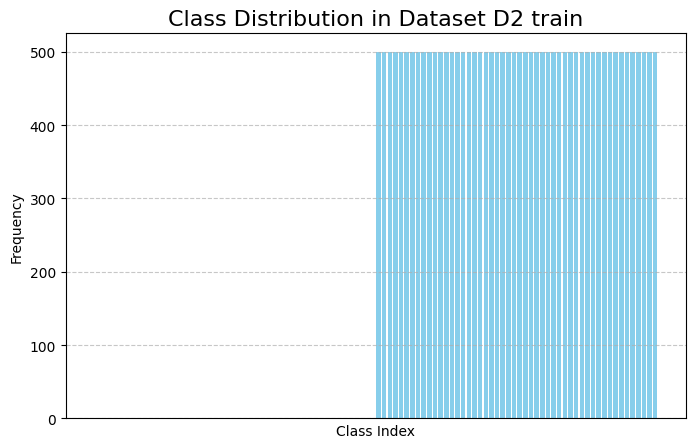

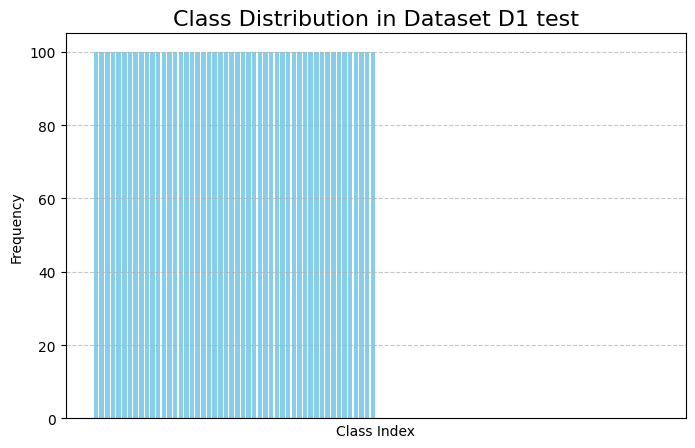

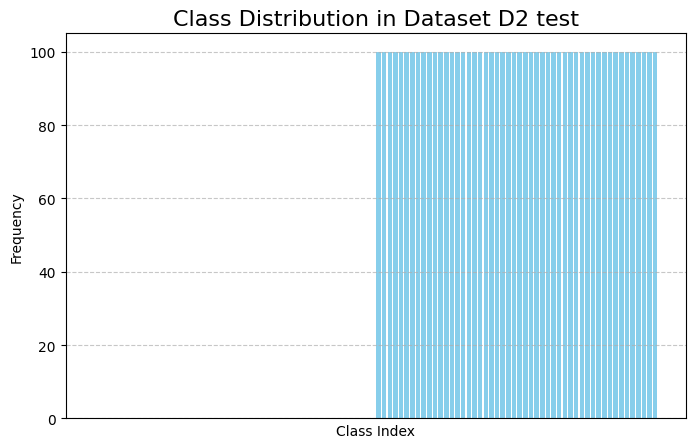

In [9]:
# Half-cifar100
config = Config(dset_pair=Dset_pairs.half_cifar100)
d1_train, d2_train, d1_test, d2_test, class_names = merge_datasets(config)

visualize_images(d1_train, class_names, title="D1 train")
visualize_images(d2_train, class_names, title="D2 train")

visualize_images(d1_test, class_names, title="D1 test")
visualize_images(d2_test, class_names, title="D2 test")

plot_class_distribution(d1_train, num_classes=len(class_names), title="D1 train")
plot_class_distribution(d2_train, num_classes=len(class_names), title="D2 train")

plot_class_distribution(d1_test, num_classes=len(class_names), title="D1 test")
plot_class_distribution(d2_test, num_classes=len(class_names), title="D2 test")

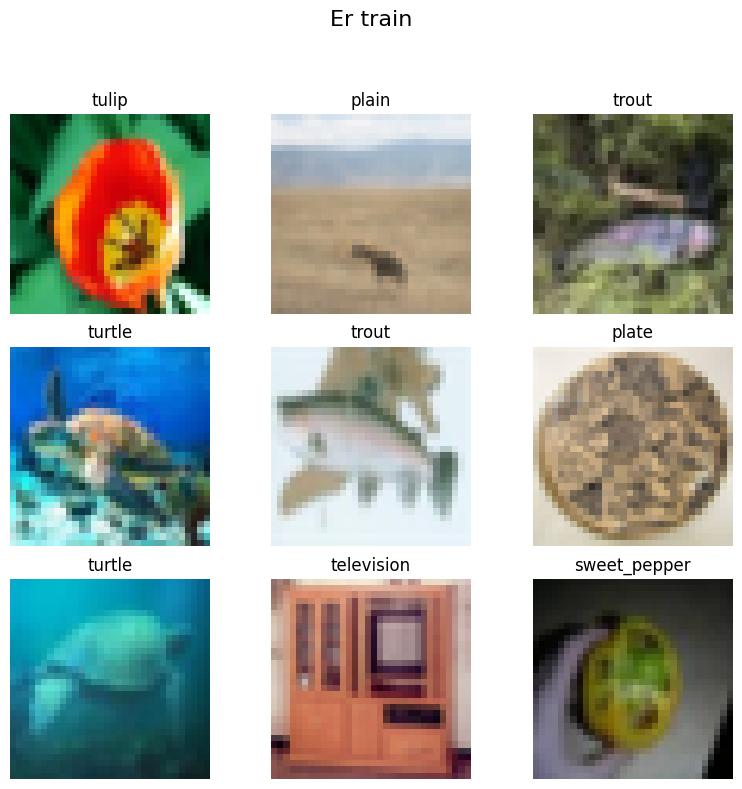

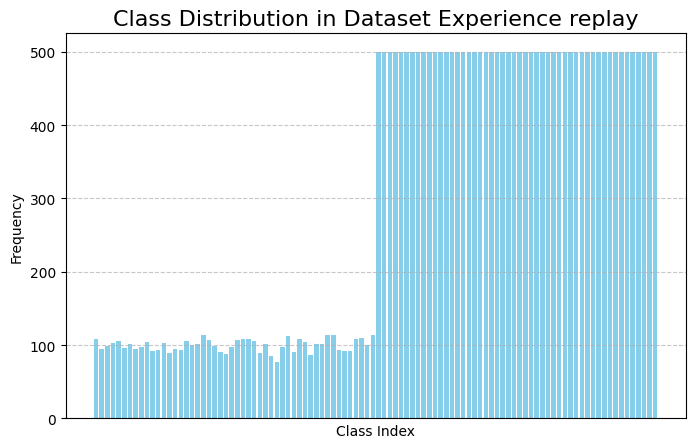

In [10]:
# Try experience replay with Half-cifar100
er_train = experience_replay(d2_train, d1_train, 0.2)
visualize_images(er_train, class_names, title="Er train")
plot_class_distribution(
    er_train, num_classes=len(class_names), title="Experience replay"
)

In [11]:
class CNNModel:
    def __init__(
        self,
        input_shape: tuple[int, int, int],
        num_classes: int,
    ) -> None:
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model: tf.keras.Model | None = None
        self.history: tf.keras.callbacks.History = None

    def build_model(self, config: Config) -> None:
        self.model = models.Sequential(
            [
                layers.InputLayer(input_shape=self.input_shape),
                layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
                layers.MaxPooling2D((2, 2)),
                layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
                layers.MaxPooling2D((2, 2)),
                layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
                layers.MaxPooling2D((2, 2)),
                layers.Flatten(),
                layers.Dense(128, activation="relu"),
                layers.Dense(self.num_classes, activation="softmax"),
            ]
        )
        self.model.compile(
            optimizer=config.optimizer,
            loss=config.loss,
            metrics=config.metrics,
        )

    def save_weights(self, filepath: Path) -> None:
        if self.model:
            self.model.save_weights(filepath)
        else:
            raise ValueError("Model is not built. Call 'build_model()' first.")

    def load_weights(self, filepath: Path) -> None:
        if self.model:
            self.model.load_weights(filepath)
        else:
            raise ValueError("Model is not built. Call 'build_model()' first.")

    def plot_training_curves(self, save_path: Path | None = None) -> None:
        if self.history is None:
            raise ValueError("Please train the model before!")

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(self.history.history["accuracy"], label="Train Accuracy")
        plt.plot(self.history.history["val_accuracy"], label="Val Accuracy")
        plt.title("Accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(self.history.history["loss"], label="Train Loss")
        plt.plot(self.history.history["val_loss"], label="Val Loss")
        plt.title("Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()

        if save_path is not None:
            plt.savefig(save_path)

        plt.show()

    def train(
        self,
        train_dset: tf.data.Dataset,
        val_dset: tf.data.Dataset,
        epochs: int,
    ) -> None:
        if self.model:
            self.history = self.model.fit(
                train_dset, epochs=epochs, validation_data=val_dset
            )
        else:
            raise ValueError("Model is not built. Call 'build_model()' first.")

    def test_model(self, test_data: tf.data.Dataset) -> tuple[float, float]:
        if self.model:
            test_loss, test_accuracy = self.model.evaluate(test_data)
            print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
            return test_loss, test_accuracy
        else:
            raise ValueError("Model is not built. Call 'build_model()' first.")

On réalise un petit essai d'entrainement sans sauvegarder quoi que ce soit pour s'assurer que le code fonctionne correctement.

/home/max/miniconda3/envs/numerical/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/10


I0000 00:00:1739227739.682596  185181 cuda_dnn.cc:529] Loaded cuDNN version 90300


391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4524 - loss: 1.2892 - val_accuracy: 0.6546 - val_loss: 0.8262
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6896 - loss: 0.8017 - val_accuracy: 0.7338 - val_loss: 0.7014
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7506 - loss: 0.6648 - val_accuracy: 0.7500 - val_loss: 0.6712
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7823 - loss: 0.5852 - val_accuracy: 0.7774 - val_loss: 0.6161
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8078 - loss: 0.5183 - val_accuracy: 0.7908 - val_loss: 0.5902
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8307 - loss: 0.4594 - val_accuracy: 0.7924 - val_loss: 0.6001
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8485 - loss: 0.4099 - val_accuracy: 0.7860 - val_loss: 0.6323
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8689 - loss: 0.3596 - val_accuracy: 0.7820 - val_

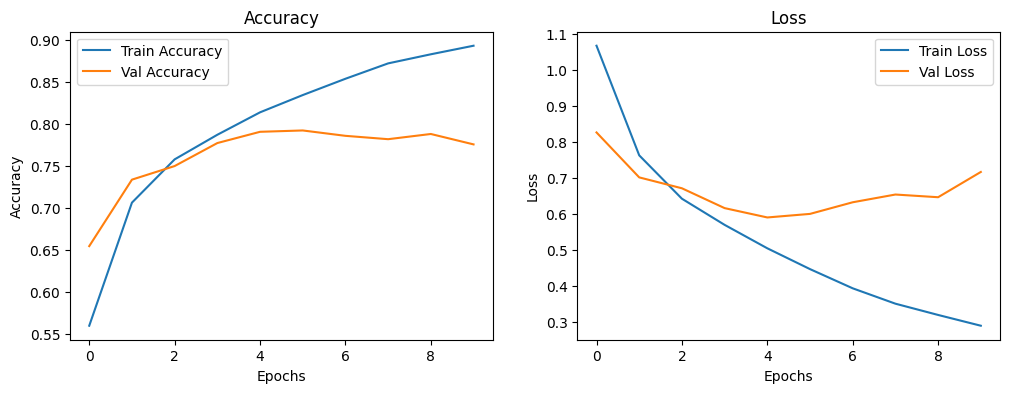

In [12]:
config = Config(dset_pair=Dset_pairs.half_cifar10, epochs=10)
d1_train, d2_train, d1_test, d2_test, class_names = merge_datasets(config)

cnn = CNNModel(config.input_shape, num_classes=len(class_names))
cnn.build_model(config)

cnn.train(train_dset=d1_train, val_dset=d1_test, epochs=config.epochs)
cnn.plot_training_curves()

L'entrainement de classification sur CIFAR-10 semble donner de bon résultats en seulement quelques epochs. En revanche l'architecture actuelle stagne très vite. On essaye d'effectuer le transfert d'entrainement dans la suite.

In [9]:
# There's 2 trainings, the first one in 100/0 proportion, loss and accuracy
# are with respect to validation set
@dataclass
class Results:
    save_dir: Path
    config: Config

    training_1_d1_accuracy: float | None = None
    training_1_d1_loss: float | None = None
    training_1_d2_accuracy: float | None = None
    training_1_d2_loss: float | None = None

    training_2_d1_accuracy: float | None = None
    training_2_d1_loss: float | None = None
    training_2_d2_accuracy: float | None = None
    training_2_d2_loss: float | None = None

    # As I am using config that has a tuple of an enum in its field turning it
    # into a dict causes issue so I just convert it to a regular tuple of str before saving it
    def save(self) -> None:
        save_output = results.save_dir / "results.json"
        self.config.dset_pair = tuple(item.value for item in self.config.dset_pair)  # type: ignore
        self.save_dir = self.save_dir.as_posix()  # type: ignore
        with open(save_output, "w") as file:
            json.dump(asdict(results), file, indent=1)

On va effectuer des entrainements dans différentes situations avec et sans experience replay.

Epoch 1/10


/home/max/miniconda3/envs/numerical/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.4523 - loss: 1.2920 - val_accuracy: 0.6658 - val_loss: 0.8293
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.6939 - loss: 0.7973 - val_accuracy: 0.7316 - val_loss: 0.7094
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.7524 - loss: 0.6610 - val_accuracy: 0.7450 - val_loss: 0.6786
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.7849 - loss: 0.5749 - val_accuracy: 0.7706 - val_loss: 0.6321
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.8144 - loss: 0.5048 - val_accuracy: 0.7848 - val_loss: 0.6058
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.8397 - loss: 0.4376 - val_accuracy: 0.7870 - val_loss: 0.6096
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.8552 - loss: 0.3900 - val_accuracy: 0.7874 - val_loss: 0.6034
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.8728 - loss: 0.3457 - val_accurac

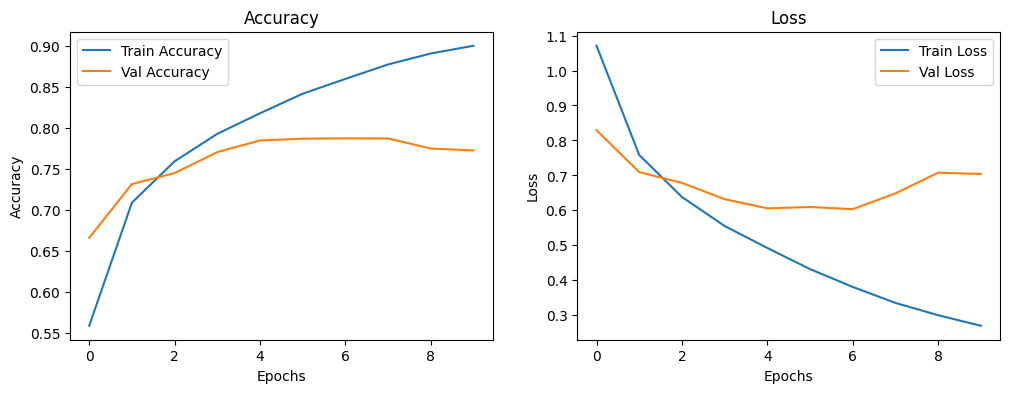

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7738 - loss: 0.6977
Test Loss: 0.7041, Test Accuracy: 0.7726
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0000e+00 - loss: 18.0353
Test Loss: 17.9671, Test Accuracy: 0.0000
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.5265 - loss: 1.6237 - val_accuracy: 0.7908 - val_loss: 0.5724
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.7927 - loss: 0.5617 - val_accuracy: 0.8286 - val_loss: 0.4705
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8353 - loss: 0.4534 - val_accuracy: 0.8516 - val_loss: 0.4162
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.8627 - loss: 0.3791 - val_accuracy: 0.8542 - val_loss: 0.4072
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8824 - loss: 0.3247 - val_accuracy: 0.8258 - val_loss: 0.4692
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.8971 - loss: 0.2799 - val_accuracy: 0.8386 - v

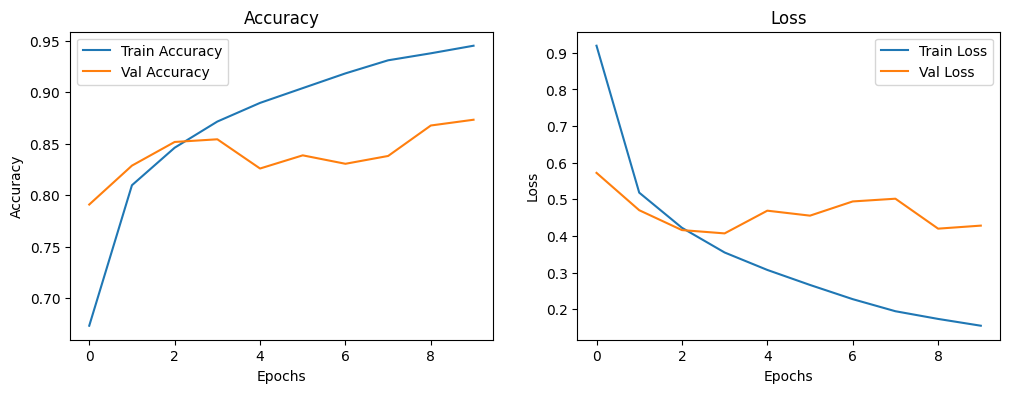

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.0000e+00 - loss: 20.5645
Test Loss: 20.4880, Test Accuracy: 0.0000
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8710 - loss: 0.4289
Test Loss: 0.4284, Test Accuracy: 0.8732


Results(
    save_dir='data/half-cifar10',
    config=Config(
        batch_size=64,
        epochs=10,
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy'],
        dset_pair=('cifar10', 'cifar10'),
        p=1.0
    ),
    training_1_d1_accuracy=0.772599995136261,
    training_1_d1_loss=0.7040999531745911,
    training_1_d2_accuracy=0.0,
    training_1_d2_loss=17.967052459716797,
    training_2_d1_accuracy=0.0,
    training_2_d1_loss=20.487964630126953,
    training_2_d2_accuracy=0.873199999332428,
    training_2_d2_loss=0.42841407656669617
)

In [12]:
# Load config, dsets and and the model
config = Config(dset_pair=Dset_pairs.half_cifar10, epochs=10)
set_seed(1234)
d1_train, d2_train, d1_test, d2_test, merged_class_names = merge_datasets(config)

results = Results(config=config, save_dir=Path("data/half-cifar10"))
os.makedirs(results.save_dir, exist_ok=True)

cnn = CNNModel(
    config.input_shape,
    len(merged_class_names),
)
cnn.build_model(config)

# Train the model on the D1 (with D1 val)
cnn.train(train_dset=d1_train, val_dset=d1_test, epochs=config.epochs)

# Save the model, nomenclature for weights D1-D2-proportion in the dset
cnn.save_weights(results.save_dir / "half-cifar10-100-0.weights.h5")
cnn.plot_training_curves(save_path=results.save_dir / "training_1_curves.png")

# Test model on D1-test and D2-test, obviously catastrophic performance on D2
d1_test_loss, d1_test_accuracy = cnn.test_model(test_data=d1_test)
d2_test_loss, d2_test_accuracy = cnn.test_model(test_data=d2_test)

results.training_1_d1_accuracy = d1_test_accuracy
results.training_1_d1_loss = d1_test_loss
results.training_1_d2_accuracy = d2_test_accuracy
results.training_1_d2_loss = d2_test_loss

# Retrain it on D2 this time (with D2-val)
cnn.train(train_dset=d2_train, val_dset=d2_test, epochs=config.epochs)

# Save the model, nomenclature for weights p in the dset
cnn.save_weights(results.save_dir / f"half-cifar10-{int(config.p * 100)}.weights.h5")
cnn.plot_training_curves(save_path=results.save_dir / "training_2_curves.png")

# Test model on D1-test and D2-test
d1_test_loss, d1_test_accuracy = cnn.test_model(test_data=d1_test)
d2_test_loss, d2_test_accuracy = cnn.test_model(test_data=d2_test)

results.training_2_d1_accuracy = d1_test_accuracy
results.training_2_d1_loss = d1_test_loss
results.training_2_d2_accuracy = d2_test_accuracy
results.training_2_d2_loss = d2_test_loss

# Saving results
results.save()
rich.print(results)

In [ ]:
# ------------------------------- Now we use experience replay with cifar10 -------------------------------
# Same as before, loading the config
config = Config(dset_pair=Dset_pairs.half_cifar10, p=0.2, epochs=10)
set_seed(1234)
d1_train, d2_train, d1_test, d2_test, merged_class_names = merge_datasets(config)

results = Results(config=config, save_dir=Path("data/half-cifar10-with-er"))
os.makedirs(results.save_dir, exist_ok=True)

cnn = CNNModel(
    config.input_shape,
    len(merged_class_names),
)
cnn.build_model(config)

# First training step, onyl done on D1
cnn.train(train_dset=d1_train, val_dset=d1_test, epochs=config.epochs)

# Test model on D1-test and D2-test, obviously catastrophic performance on D2
d1_test_loss, d1_test_accuracy = cnn.test_model(test_data=d1_test)
d2_test_loss, d2_test_accuracy = cnn.test_model(test_data=d2_test)

results.training_1_d1_accuracy = d1_test_accuracy
results.training_1_d1_loss = d1_test_loss
results.training_1_d2_accuracy = d2_test_accuracy
results.training_1_d2_loss = d2_test_loss

# Apply experience replay
mixed_train_dset = experience_replay(d2_train, d1_train, p=config.p)

# Apply the second training phase
cnn.train(train_dset=mixed_train_dset, val_dset=d2_test, epochs=config.epochs)

# Save the model, nomenclature for weights p in the dset
cnn.save_weights(results.save_dir / f"half-cifar10-{int(config.p * 100)}.weights.h5")
cnn.plot_training_curves(save_path=results.save_dir / "training_2_curves.png")

# Finally retest the model on D1 and D2 test
d1_test_loss, d1_test_accuracy = cnn.test_model(test_data=d1_test)
d2_test_loss, d2_test_accuracy = cnn.test_model(test_data=d2_test)

results.training_2_d1_accuracy = d1_test_accuracy
results.training_2_d1_loss = d1_test_loss
results.training_2_d2_accuracy = d2_test_accuracy
results.training_2_d2_loss = d2_test_loss

# Saving results
results.save()
rich.print(results)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4524 - loss: 1.2892 - val_accuracy: 0.6546 - val_loss: 0.8262
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6896 - loss: 0.8017 - val_accuracy: 0.7338 - val_loss: 0.7014
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7506 - loss: 0.6648 - val_accuracy: 0.7500 - val_loss: 0.6712
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7823 - loss: 0.5852 - val_accuracy: 0.7774 - val_loss: 0.6161
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8078 - loss: 0.5183 - val_accuracy: 0.7908 - val_loss: 0.5902
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8307 - loss: 0.4594 - val_accuracy: 0.7924 - val_loss: 0.6001
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8485 - loss: 0.4099 - val_accuracy: 0.7860 - val_loss: 0.6323
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8689 - loss: 0.3596 - val_accuracy: 0.